AI-Powered Employee Attrition Prediction System
Kaggle Dataset
🏆 IBM HR Analytics Employee Attrition & Performance
Kaggle:
 https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

Real Business Problem
An organization loses employees every month.
HR wants to predict:
Which employees are likely to leave
Why they may leave
Which factors influence attrition
Risk category of employees

Student Deliverables
Phase 1 — EDA
Identify:
Attrition rate
Department-wise attrition
Gender-wise attrition
Salary impact
Experience impact

Phase 2 — Machine Learning
Logistic Regression
Predict:
Attrition = Yes / No

Decision Tree
Generate HR decision rules.
Example:
IF
JobSatisfaction < 2
AND
MonthlyIncome < 4000

THEN
High Attrition Risk

Random Forest
Build production model.

SVM
Compare accuracy.

KNN
Find similar employees.

Naive Bayes
Probability-based prediction.

PCA
Dimensionality reduction.

K-Means
Employee Segmentation:
Cluster 1:
High Performers

Cluster 2:
At Risk

Cluster 3:
New Employees

AWS Requirements
S3
Store:
dataset/
model/
reports/

SageMaker
Train:
logistic_regression.pkl
random_forest.pkl

Endpoint
Deploy:
employee-attrition-predictor

Lambda
Input:
{
 "Age": 35,
 "MonthlyIncome": 4500,
 "JobSatisfaction": 2
}

API Gateway
POST /predict

Output
{
 "attrition_probability": 87.3,
 "risk_level": "HIGH"
}


In [50]:
 import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)


IndentationError: unexpected indent (4054125979.py, line 1)

In [ ]:
import pandas as pd
import os

In [ ]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download(
    "pavansubhasht/ibm-hr-analytics-attrition-dataset"
)

print("Path to dataset files:", path)

Path to dataset files: C:\Users\lekha\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1


In [ ]:
import os

print(os.listdir(path))

['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [ ]:
csv_file=os.path.join(path,"WA_Fn-UseC_-HR-Employee-Attrition.csv")

df=pd.read_csv(csv_file)

print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [ ]:
print(df.shape)

print(df.columns)

print(df.info())

(1470, 35)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attr

In [ ]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:
#Attrition Rate
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [ ]:
attrition_rate=(df['Attrition'].value_counts(normalize=True)*100)

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


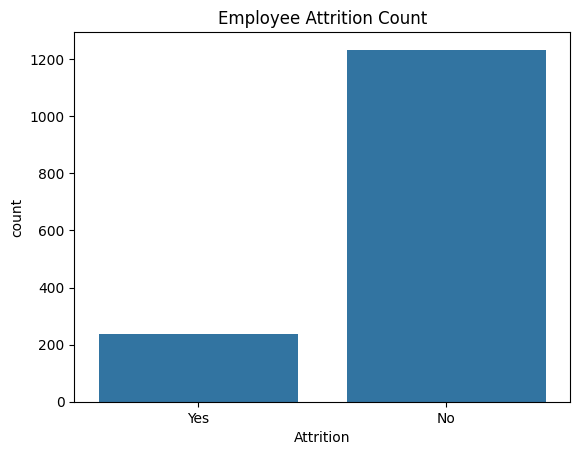

In [ ]:
#Visuallization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='Attrition',
    data=df
)
plt.title("Employee Attrition Count")
plt.show()

In [ ]:
dept_attrition=pd.crosstab(
    df['Department'],
    df['Attrition']
)

print(dept_attrition)

Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


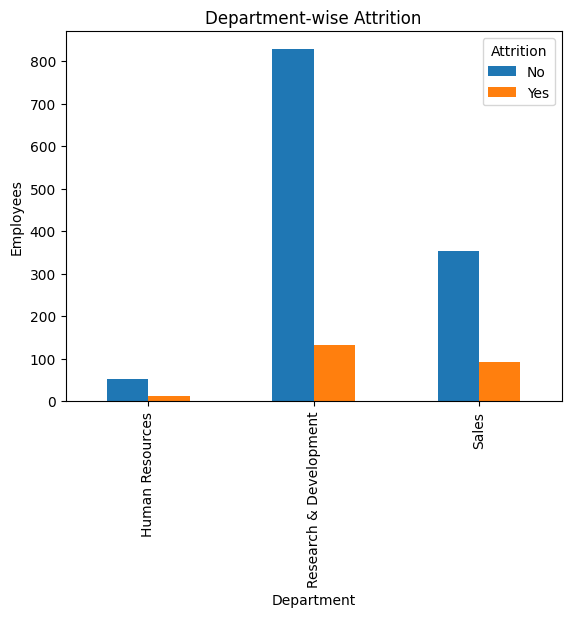

In [ ]:
dept_attrition.plot(kind='bar')
plt.title("Department-wise Attrition")
plt.ylabel("Employees")
plt.show()

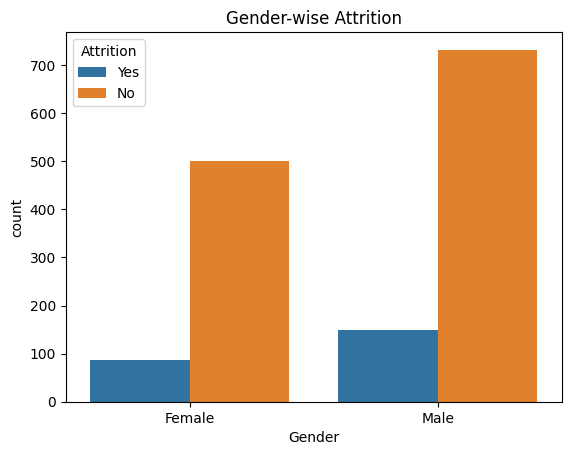

In [ ]:
sns.countplot(
    x='Gender',
    hue='Attrition',
    data=df
)

plt.title("Gender-wise Attrition")
plt.show()


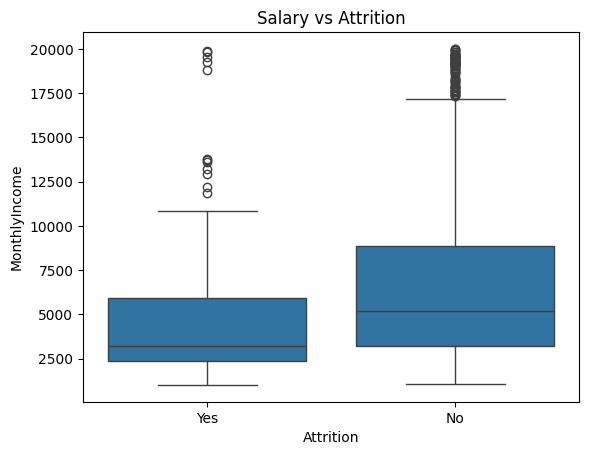

In [ ]:
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)
plt.title("Salary vs Attrition")
plt.show()

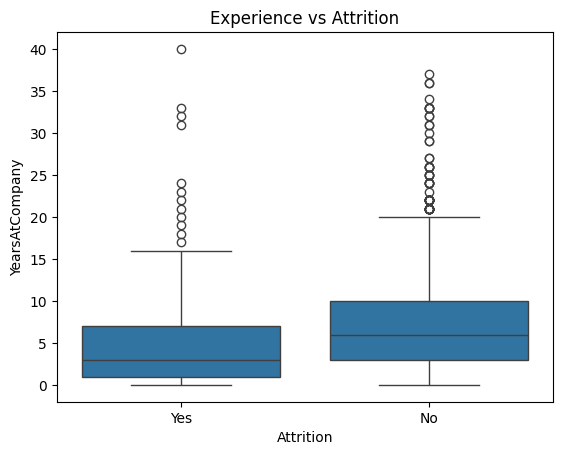

In [ ]:
sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)
plt.title("Experience vs Attrition")
plt.show()

Phase2 - Machine Learning


In [ ]:
df['Attrition']=df['Attrition'].map({
    'Yes':1,
    'No':0
})

In [ ]:
print(df['Attrition'].head())

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col]=le.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
X=df.drop('Attrition',axis=1)
y=df['Attrition']

In [ ]:
print(X.head())


   Age  BusinessTravel  DailyRate  Department  DistanceFromHome  Education  \
0   41               2       1102           2                 1          2   
1   49               1        279           1                 8          1   
2   37               2       1373           1                 2          2   
3   33               1       1392           1                 3          4   
4   27               2        591           1                 2          1   

   EducationField  EmployeeCount  EmployeeNumber  EnvironmentSatisfaction  \
0               1              1               1                        2   
1               1              1               2                        3   
2               4              1               4                        4   
3               1              1               5                        4   
4               3              1               7                        1   

   ...  RelationshipSatisfaction  StandardHours  StockOptionLevel  \

In [ ]:
print(y.head())

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1176, 34)
(294, 34)
(1176,)
(294,)


In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr=LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled,y_train)
y_pred=lr.predict(X_test_scaled)


In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)

accuracy: 0.891156462585034


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

accuracy_dt=accuracy_score(y_test,y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.8299319727891157


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plt_tree(
    dt,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

accuracy_rf=accuracy_score(y_test,y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8673469387755102


In [ ]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(X_train_scaled,y_train)
y_pred_svm=svm.predict(X_test_scaled)

accuracy_svm=accuracy_score(
    y_test,y_pred_svm
)

print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.8843537414965986


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.8741496598639455


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.8401360544217688


In [57]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

print("\nOriginal Shape:")
print(X_train_scaled.shape)

print("\nPCA Shape:")
print(X_pca.shape)



Original Shape:
(1176, 34)

PCA Shape:
(1176, 2)


In [ ]:
print("\nExplained Variance Ratio:")

print(pca.explained_variance_ratio_)

print("\nTotal Variance Retained:")

print(sum(pca.explained_variance_ratio_))

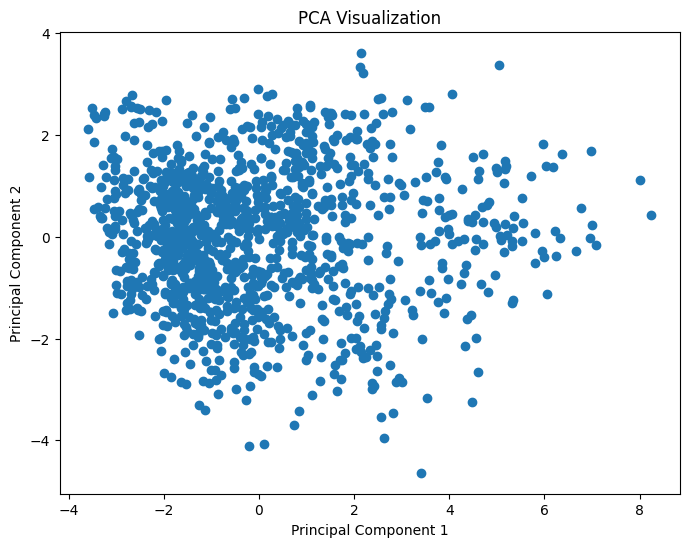

In [58]:

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Visualization")

plt.show()

In [62]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)
clusters = kmeans.fit_predict(
    X_pca
)

In [ ]:

df['Cluster'] = kmeans.predict(scaler.transform(X))

X_scaled = scaler.transform(X)

X_pca_full = pca.transform(X_scaled)

df['Cluster'] = kmeans.predict(X_pca_full)
print(df[['Attrition', 'Cluster']].head())


In [ ]:
loaded_model = joblib.load(
    "logistic_regression.pkl"
)

In [ ]:
models = {
    "Logistic Regression": accuracy,
    "Decision Tree": accuracy_dt,
    "Random Forest": accuracy_rf,
    "SVM": accuracy_svm,
    "KNN": accuracy_knn,
    "Naive Bayes": accuracy_nb
}

for model, acc in models.items():
    print(model, ":", acc)

Logistic Regression : 0.891156462585034
Decision Tree : 0.8299319727891157
Random Forest : 0.8673469387755102
SVM : 0.8843537414965986
KNN : 0.8741496598639455
Naive Bayes : 0.8401360544217688


In [53]:
import joblib

joblib.dump(
    lr,
    "logistic_regression.pkl"
)

print("Logistic Regression Model Saved")

Logistic Regression Model Saved


In [54]:
loaded_model = joblib.load(
    "logistic_regression.pkl"
)

In [56]:
from sklearn.metrics import confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))

Confusion Matrix:
 [[249   6]
 [ 26  13]]
